# CEO Social Capital — Research Summary

Visualises the outputs of `07_run_research.py` and `08_run_econometrics_and_portfolio.py`.

**Factor**: `n_unique_connected_rank` — cross-sectional percentile rank of cumulative unique director connections per CEO per year.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

OUT = '../data/processed'

## 1. Information Coefficient (IC & Rank IC)

In [2]:
ic = pd.read_csv(os.path.join(OUT, 'ic_timeseries.csv'), index_col=0)
ic.index.name = 'year'
ic.head()

,ic,rank_ic
year,,
2000,0.058359,-0.020456
2001,-0.053665,-0.099482
2002,-0.005214,0.025545
2003,-0.045447,-0.014022
2004,0.004983,0.033413


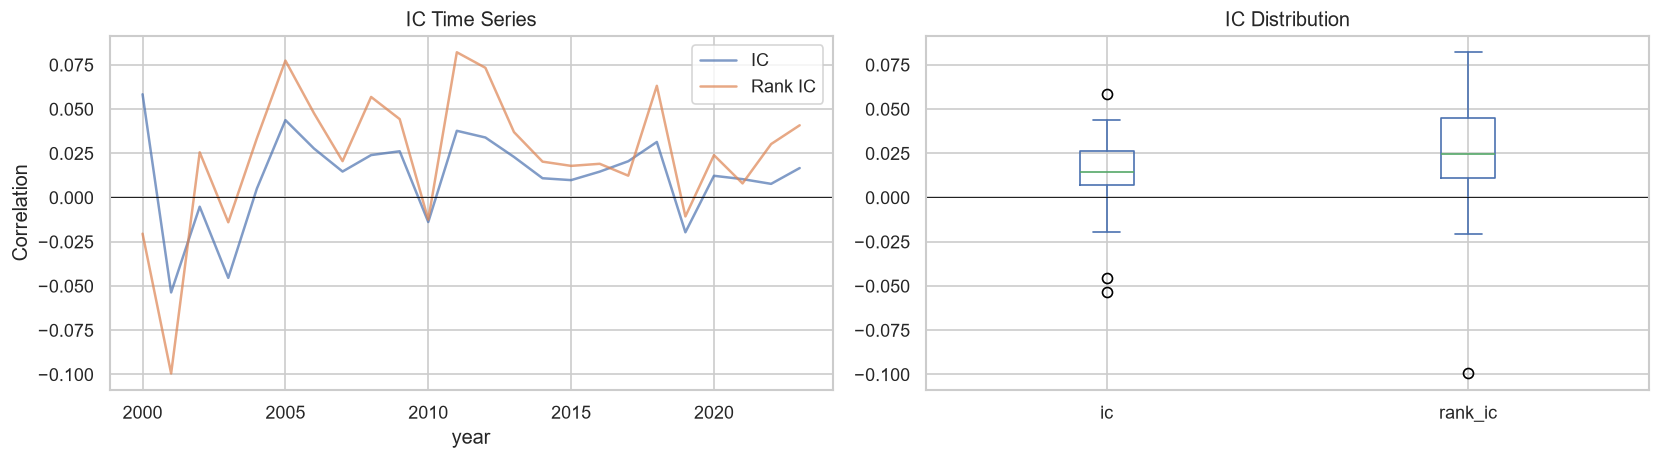

IC  summary: {'mean': np.float64(0.012098161140550664), 'std': np.float64(0.025660904856954946), 'ICIR': np.float64(0.47146276438773616)}
RIC summary: {'mean': np.float64(0.024016944450186123), 'std': np.float64(0.038731896130156936), 'ICIR': np.float64(0.620081814984688)}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series
ax = axes[0]
ic['ic'].plot(ax=ax, label='IC', alpha=0.7)
ic['rank_ic'].plot(ax=ax, label='Rank IC', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('IC Time Series')
ax.set_ylabel('Correlation')
ax.legend()

# Distribution
ax = axes[1]
ic[['ic', 'rank_ic']].plot(kind='box', ax=ax)
ax.set_title('IC Distribution')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('IC  summary:', {'mean': ic['ic'].mean(),  'std': ic['ic'].std(),  'ICIR': ic['ic'].mean()  / ic['ic'].std()})
print('RIC summary:', {'mean': ic['rank_ic'].mean(), 'std': ic['rank_ic'].std(), 'ICIR': ic['rank_ic'].mean() / ic['rank_ic'].std()})

## 2. Factor Decay (Rank IC at Different Horizons)

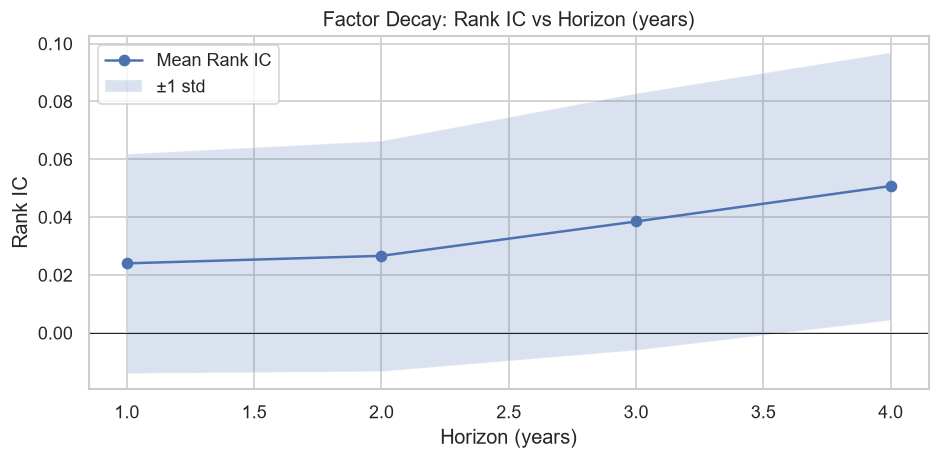

,mean_ic,std_ic,icir,pct_positive,n_periods
horizon,,,,,
1,0.024017,0.037916,0.633418,0.791667,24
2,0.026617,0.039831,0.668236,0.916667,24
3,0.038496,0.044385,0.867329,0.875000,24
4,0.050748,0.046251,1.097217,0.916667,24


In [4]:
# Factor decay is logged in the terminal output; recompute from panel if available
panel_path = os.path.join(OUT, 'panel_with_returns.parquet')
if os.path.exists(panel_path):
    from ceo_sc.research.ic import factor_decay, ic_summary
    panel = pd.read_parquet(panel_path)
    decay = factor_decay(
        panel, 'n_unique_connected_rank', 'forward_return',
        entity_col='dirid_starting', date_col='year', max_lag=4
    )
else:
    decay = pd.DataFrame()

if not decay.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    decay['mean_ic'].plot(ax=ax, marker='o', label='Mean Rank IC')
    ax.fill_between(
        decay.index,
        decay['mean_ic'] - decay['std_ic'],
        decay['mean_ic'] + decay['std_ic'],
        alpha=0.2, label='±1 std'
    )
    ax.set_title('Factor Decay: Rank IC vs Horizon (years)')
    ax.set_xlabel('Horizon (years)')
    ax.set_ylabel('Rank IC')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(decay)
else:
    print('Panel not found; factor decay table was printed to console during 07_run_research.py')

## 3. Quantile Portfolio Returns

In [5]:
quantiles = pd.read_csv(os.path.join(OUT, 'quantile_returns.csv'), index_col=0)
quantiles.index.name = 'year'
quantiles.columns = [f'Q{int(float(c))}' for c in quantiles.columns]
quantiles.head()

,Q1,Q2,Q3,Q4,Q5
year,,,,,
2000,0.095962,0.289143,0.205785,0.194724,0.335420
2001,-0.079351,0.008245,-0.065129,-0.182078,-0.123605
2002,0.630607,0.864827,0.927474,0.726967,0.678783
2003,0.314525,0.241090,0.216256,0.205404,0.231637
2004,0.089229,0.079467,0.025825,0.079965,0.103229


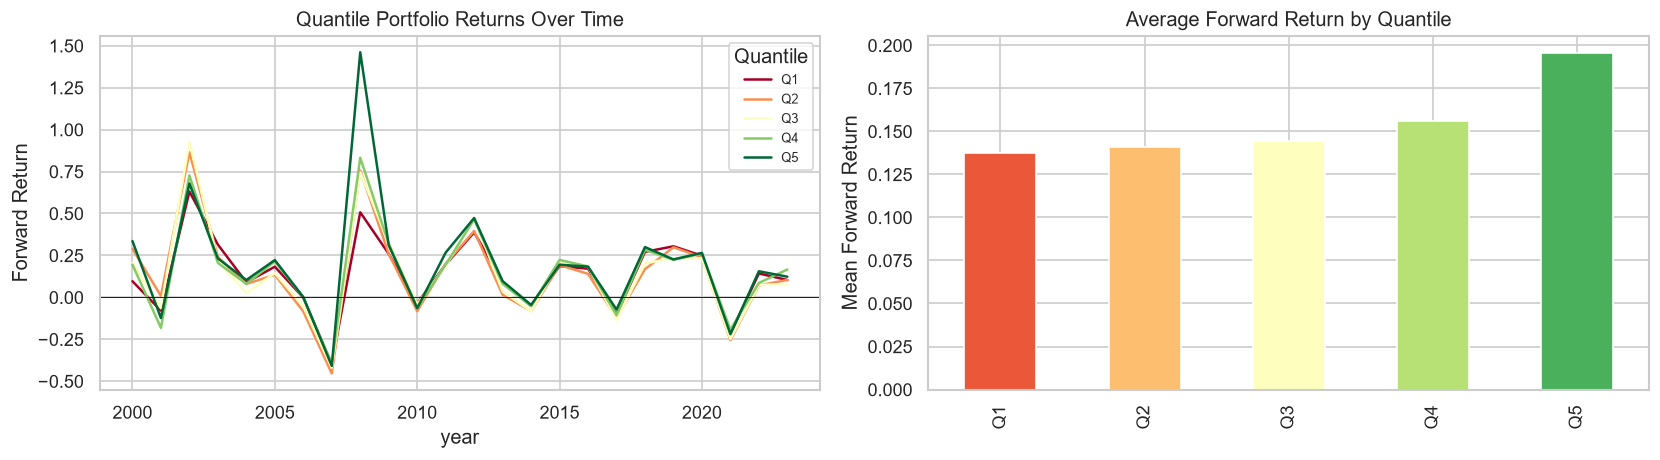

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series of all quantiles
ax = axes[0]
quantiles.plot(ax=ax, cmap='RdYlGn')
ax.set_title('Quantile Portfolio Returns Over Time')
ax.set_ylabel('Forward Return')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(title='Quantile', fontsize=8)

# Bar chart of average returns per quantile
ax = axes[1]
quantiles.mean().plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', n_colors=len(quantiles.columns)))
ax.set_title('Average Forward Return by Quantile')
ax.set_ylabel('Mean Forward Return')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Long-Short Portfolio Performance

In [7]:
ls = pd.read_csv(os.path.join(OUT, 'long_short_returns.csv'), index_col=0)
ls.index.name = 'year'
ls.head()

,long_short
year,
2000,0.239458
2001,-0.044255
2002,0.048176
2003,-0.082889
2004,0.014000


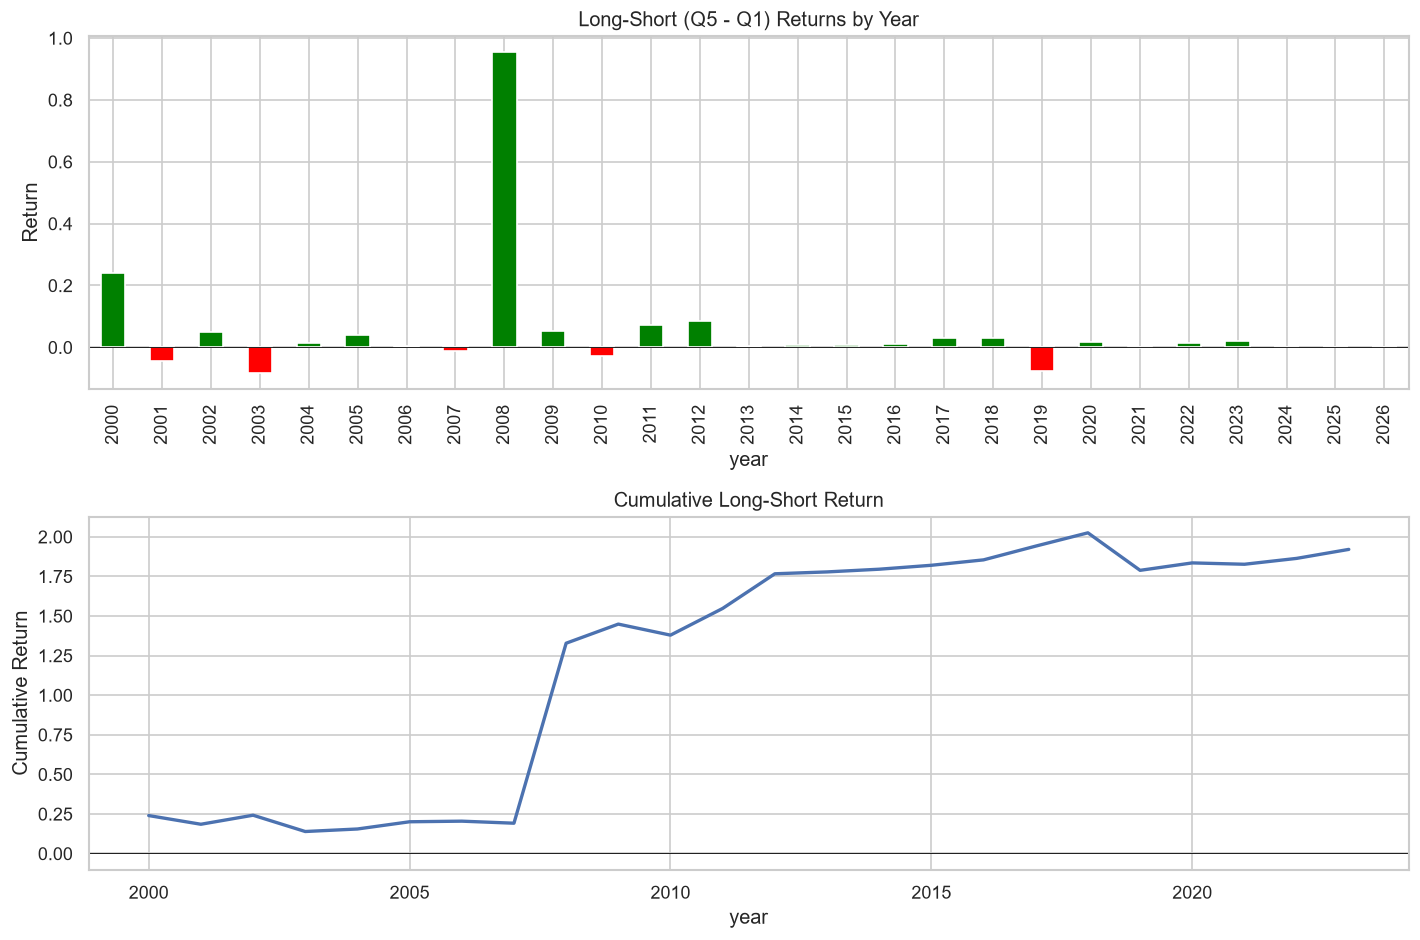

Total cumulative return: nan%
Annualized return:       5.83%
Annualized volatility:   19.62%
Sharpe ratio:            0.30


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Long-short returns per year
ax = axes[0]
colors = ['green' if v > 0 else 'red' for v in ls['long_short']]
ls['long_short'].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Long-Short (Q5 - Q1) Returns by Year')
ax.set_ylabel('Return')
ax.axhline(0, color='black', linewidth=0.5)

# Cumulative return
ax = axes[1]
cumret = (1 + ls['long_short']).cumprod() - 1
cumret.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Long-Short Return')
ax.set_ylabel('Cumulative Return')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Total cumulative return: {cumret.iloc[-1]:.2%}')
print(f'Annualized return:       {ls["long_short"].mean():.2%}')
print(f'Annualized volatility:   {ls["long_short"].std(ddof=0):.2%}')
print(f'Sharpe ratio:            {ls["long_short"].mean() / ls["long_short"].std(ddof=0):.2f}')

## 5. Rolling Sharpe Ratio

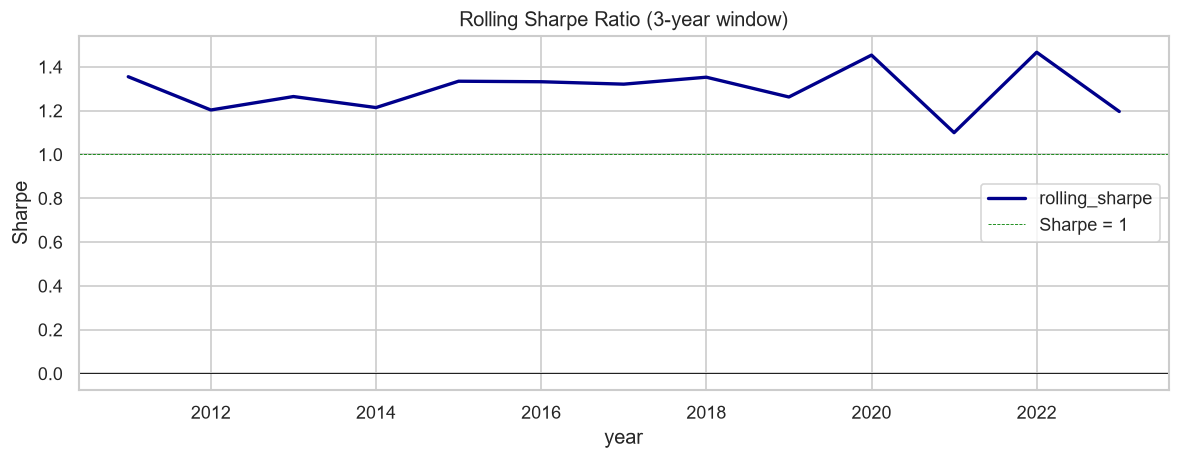

In [9]:
rs = pd.read_csv(os.path.join(OUT, 'rolling_sharpe.csv'), index_col=0)
rs.index.name = 'year'

fig, ax = plt.subplots(figsize=(10, 4))
rs['rolling_sharpe'].plot(ax=ax, linewidth=2, color='darkblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(1, color='green', linewidth=0.5, linestyle='--', label='Sharpe = 1')
ax.set_title('Rolling Sharpe Ratio (3-year window)')
ax.set_ylabel('Sharpe')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Fama-MacBeth Regression

In [10]:
fm = pd.read_csv(os.path.join(OUT, 'fama_macbeth.csv'), index_col=0)
fm

,mean,std_error,t_stat,p_value,n_periods
coefficient,,,,,
const,0.120087,0.039389,3.048756,0.002298,24
n_unique_connected_rank,0.067788,0.043837,1.546383,0.122012,24


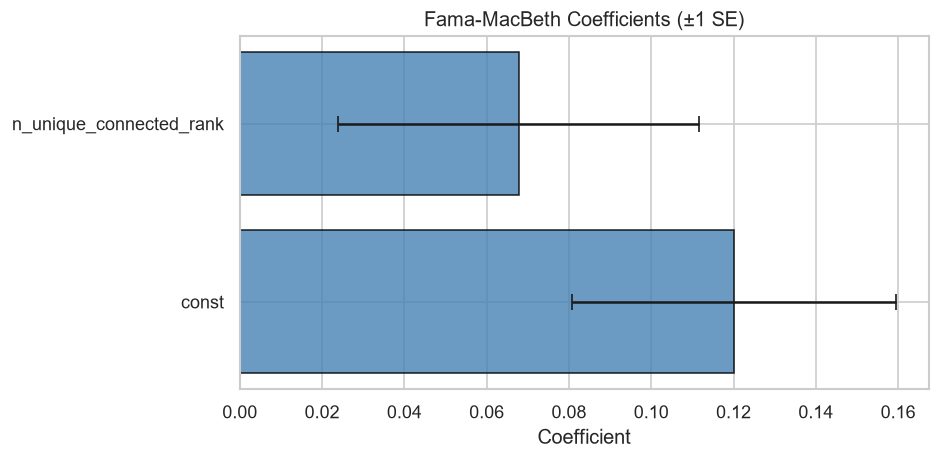

Factor t-stat: 1.55 (p = 0.1220)


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
coefs = fm['mean']
errors = fm['std_error']
ax.barh(range(len(coefs)), coefs, xerr=errors, color='steelblue', alpha=0.8,
         edgecolor='black', capsize=5)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(fm.index)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Fama-MacBeth Coefficients (±1 SE)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print(f"Factor t-stat: {fm.loc['n_unique_connected_rank', 't_stat']:.2f} "
      f"(p = {fm.loc['n_unique_connected_rank', 'p_value']:.4f})")

## 7. Robustness (With vs Without Controls)

In [ ]:
rob = pd.read_csv(os.path.join(OUT, 'robustness.csv'))
rob

,mean,std_error,t_stat,p_value,n_periods,spec,controls,coefficient
0,0.067788,0.043837,1.546383,0.122012,24.0,0,none,n_unique_connected_rank
1,0.104442,0.039870,2.619544,0.008805,24.0,1,"mkvalt,at,sale",n_unique_connected_rank


KeyError: 'mean'

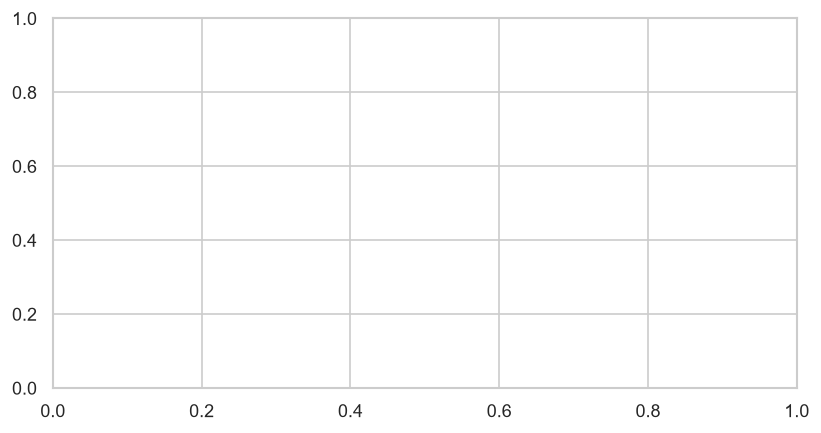

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['No controls' if c == 'none' else c for c in rob['controls']]
ax.bar(range(len(rob)), rob['mean'], yerr=rob['std_error'],
       color=['lightcoral', 'steelblue'], edgecolor='black', capsize=5)
ax.set_xticks(range(len(rob)))
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Robustness: Factor Coefficient Across Specifications')
ax.set_ylabel('Mean Coefficient')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [ ]:
print('='*60)
print('CEO SOCIAL CAPITAL FACTOR — RESEARCH SUMMARY')
print('='*60)
print()
print(f"Factor:           n_unique_connected_rank")
print(f"Sample period:    {ic.index.min()} - {ic.index.max()} ({len(ic)} years)")
print()
print('--- Information Coefficient ---')
print(f"  Mean IC:         {ic['ic'].mean():.4f}")
print(f"  Mean Rank IC:    {ic['rank_ic'].mean():.4f}")
print(f"  Rank IC IR:      {ic['rank_ic'].mean() / ic['rank_ic'].std(ddof=0):.2f}")
print(f"  % positive:      {(ic['rank_ic'] > 0).mean():.1%}")
print()
print('--- Long-Short Portfolio ---')
ann_ret = ls['long_short'].mean()
ann_vol = ls['long_short'].std(ddof=0)
print(f"  Annualized ret:  {ann_ret:.2%}")
print(f"  Annualized vol:  {ann_vol:.2%}")
print(f"  Sharpe ratio:    {ann_ret / ann_vol:.2f}")
print(f"  Cumulative ret:  {(1 + ls['long_short']).cumprod().iloc[-1] - 1:.2%}")
print()
print('--- Fama-MacBeth ---')
f = fm.loc['n_unique_connected_rank']
print(f"  Coefficient:     {f['mean']:.4f}")
print(f"  t-stat:          {f['t_stat']:.2f}")
print(f"  p-value:         {f['p_value']:.4f}")
sig = '***' if f['p_value'] < 0.01 else '**' if f['p_value'] < 0.05 else '*' if f['p_value'] < 0.10 else 'n.s.'
print(f"  Significance:    {sig}")
print('='*60)